In [1]:
import os
os.chdir("..")
root = os.getcwd()

In [2]:
import sys
sys.path.insert(0, os.path.join(root, "src"))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spo.data import fetch_vix, fetch_ff_factors
from spo.risk.decomposition import (
    compute_alpha, vol_timing_factor, tail_shape_factor, build_factor_frame,
    run_decomposition, regression_table, r2_decomposition,
    cumulative_contribution, variance_inflation_factors, orthogonalize,
    subperiod_contribution_table,
)

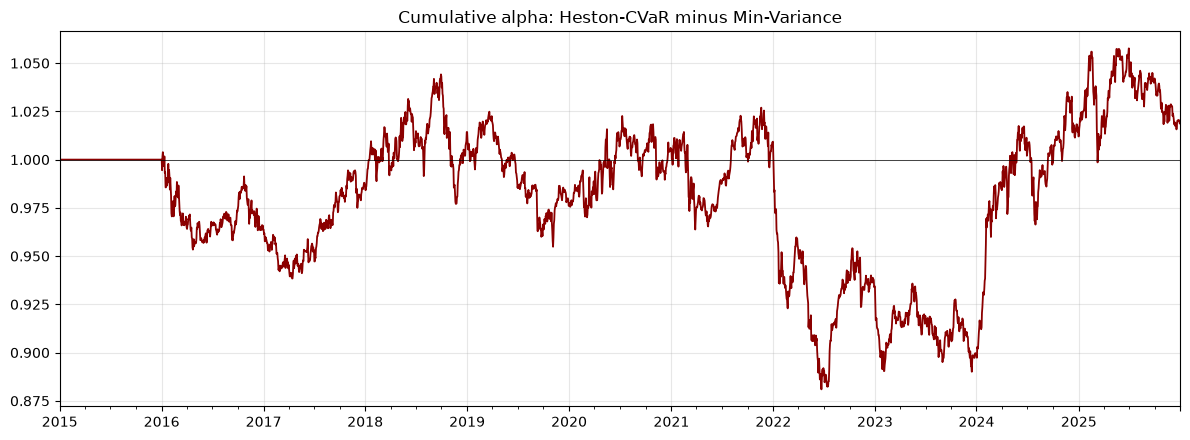

In [4]:
net_returns = pd.read_csv("results/sp500/net_returns.csv", index_col=0, parse_dates=True)
alpha = compute_alpha(net_returns, "Heston-CVaR", "Min-Variance")

fig, ax = plt.subplots(figsize=(12, 4.5))
(1 + alpha).cumprod().plot(ax=ax, color="darkred", lw=1.3)
ax.axhline(1.0, color="black", lw=0.5)
ax.set_title("Cumulative alpha: Heston-CVaR minus Min-Variance")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
vix = pd.read_parquet("data/processed/vix.parquet")["VIX"]
vt = vol_timing_factor(vix)

In [6]:
panel = pd.read_parquet("data/processed/sp500_log_returns.parquet")
ts = tail_shape_factor(panel, window=21)

In [7]:
ff = pd.read_parquet("data/processed/ff5_factors.parquet")
alpha_aligned, factors = build_factor_frame(alpha, vt, ts, ff)
print(f"{len(alpha_aligned)} aligned observations, {factors.index.min().date()} to {factors.index.max().date()}")

2764 aligned observations, 2015-01-05 to 2025-12-30


In [8]:
model = run_decomposition(alpha_aligned, factors)
table = regression_table(model)
print(f"R^2 = {table.attrs['r_squared']:.3f}   n = {table.attrs['n_obs']}")
table.style.format({"coef": "{:.5f}", "t_stat": "{:.2f}", "p_value": "{:.3f}"})

R^2 = 0.165   n = 2764


,coef,t_stat,p_value
const,-0.00004,-0.60,0.548
VT,-0.00021,-3.47,0.001
TS,0.00000,0.94,0.346
Mkt-RF,0.03231,2.92,0.004
SMB,-0.04164,-3.08,0.002
HML,-0.10800,-8.16,0.000
RMW,-0.04885,-2.59,0.010
CMA,0.01410,0.54,0.592


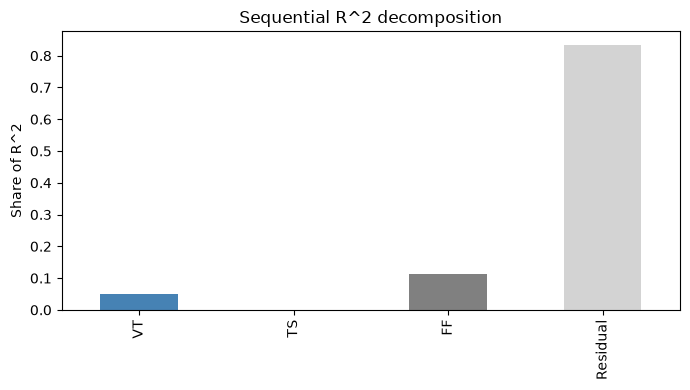

In [9]:
r2_shares = r2_decomposition(alpha_aligned, factors)
fig, ax = plt.subplots(figsize=(7, 4))
r2_shares.plot.bar(ax=ax, color=["steelblue", "darkorange", "gray", "lightgray"])
ax.set_title("Sequential R^2 decomposition")
ax.set_ylabel("Share of R^2")
plt.tight_layout(); plt.show()

Total realized alpha over the sample: 0.0352.


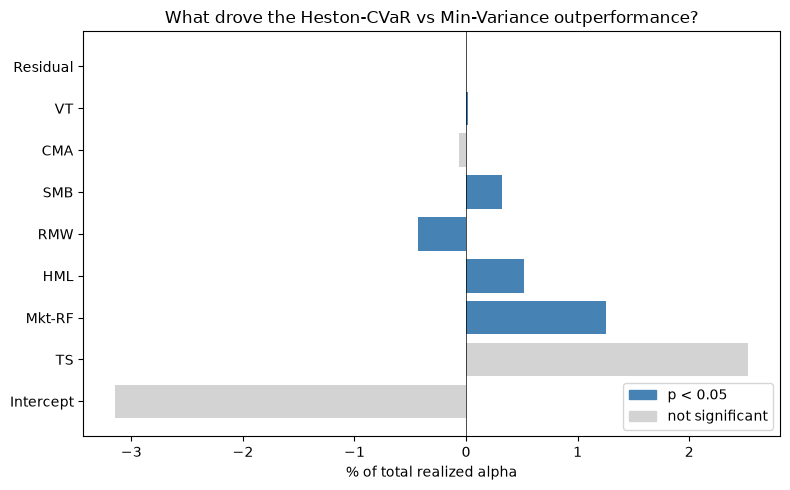

In [10]:
p_values = table["p_value"].rename(index={"const": "Intercept"})

contrib = cumulative_contribution(model, factors, alpha_aligned)
contrib_sorted = contrib.reindex(contrib["pct_of_total_alpha"].abs().sort_values(ascending=False).index)

# Residual has no regression coefficient / p-value -- treat as not significant,
# same as it isn't a robust driver either.
significant = (p_values.reindex(contrib_sorted.index) < 0.05).fillna(False)
colors = ["steelblue" if sig else "lightgray" for sig in significant]

print(f"Total realized alpha over the sample: {alpha_aligned.sum():.4f}.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(contrib_sorted.index, contrib_sorted["pct_of_total_alpha"], color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_title("What drove the Heston-CVaR vs Min-Variance outperformance?")
ax.set_xlabel("% of total realized alpha")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="steelblue", label="p < 0.05"),
        plt.Rectangle((0, 0), 1, 1, color="lightgray", label="not significant"),
    ],
    loc="lower right",
)
plt.tight_layout(); plt.show()

In [11]:
ts_orth = orthogonalize(factors["TS"], factors["VT"])
factors_orth = factors.drop(columns=["TS"]).assign(TS=ts_orth)
model_orth = run_decomposition(alpha_aligned, factors_orth)

comparison = pd.concat({
    "original": regression_table(model)["coef"],
    "orthogonalized": regression_table(model_orth)["coef"],
}, axis=1)
comparison

,original,orthogonalized
const,-0.000040,-0.000008
VT,-0.000212,-0.000211
TS,0.000001,0.000001
Mkt-RF,0.032312,0.032312
SMB,-0.041636,-0.041636
HML,-0.107998,-0.107998
RMW,-0.048855,-0.048855
CMA,0.014102,0.014102


In [12]:
subperiods = subperiod_contribution_table(model, factors, alpha_aligned)
subperiods.style.format("{:.1%}")

,Full sample,2020 (COVID),2022 (rate hikes)
VT,2.1%,-6.0%,1.3%
TS,253.0%,9.5%,-3.1%
Mkt-RF,125.0%,27.6%,8.8%
SMB,32.4%,-7.5%,-0.4%
HML,52.0%,112.6%,39.1%
RMW,-43.3%,4.1%,4.3%
CMA,-6.7%,-4.1%,-4.8%
Intercept,-314.5%,-32.0%,13.4%
Residual,-0.0%,-4.3%,41.5%
